# Sprint 2 Final Integration Notebook
This notebook demonstrates final sprint 2 pipeline, which includes:
- final activity-based outcome
- time-based train/validation/test split
- prefix-level data generation
- process-aware feature encoding
- training majority baseline model
- training logistic regression
- training random forest 
- selecting random forest configuration on validation data 
- model evaluation on test set
- first shap experiment



## 1. Imports and project setup

In [63]:
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [64]:
import pandas as pd
import numpy as np

from src.data_extraction.extract import import_data, split
from src.feature_engineering.outcome_labelling import outcome
from src.feature_engineering.prefix_generation import generate_prefix
from src.feature_engineering.feature_encoding import Encode

from src.modeling.models import train_logistic_regression
from src.modeling.model_selection import select_best_random_forest
from src.modeling.evaluation import evaluate_model, build_evaluation_table

## 2. Load data

In [65]:
from scripts.download_data import download_dataset

# Download the event log on first run (idempotent); returns the .xes path.
data_path = download_dataset()

drop_columns = ["impact", "org:role"]

df = import_data(str(data_path), drop_columns=drop_columns)

df.head()

Event log already present: /Users/alex/Desktop/temp/explainable-process-prediction/data/raw/BPI_Challenge_2013_incidents/BPI_Challenge_2013_incidents.xes
Documentation already present: /Users/alex/Desktop/temp/explainable-process-prediction/data/raw/BPI_Challenge_2013_incidents/DATA.xml


parsing log, completed traces :: 100%|██████████| 7554/7554 [00:01<00:00, 5528.54it/s]


      org:group resource country organization country org:resource  \
0           V30           France                   fr     Frederic   
1           V30           France                   fr     Frederic   
2        V5 3rd           France                   fr     Frederic   
3        V5 3rd           France                   fr  Anne Claire   
4           V30           France                   fr  Anne Claire   
...         ...              ...                  ...          ...   
65528        C9           Brazil                   br      Lierson   
65529        C9           Brazil                   br      Lierson   
65530        C9           Brazil                   br      Lierson   
65531        C9           Brazil                   br      Lierson   
65532       N36              USA                   us         Matt   

      organization involved concept:name  product lifecycle:transition  \
0               Org line A2     Accepted  PROD582          In Progress   
1          

,org:group,resource country,organization country,org:resource,organization involved,concept:name,product,lifecycle:transition,time:timestamp,case:concept:name
0,V30,France,fr,Frederic,Org line A2,Accepted,PROD582,In Progress,2010-03-31 16:59:42+00:00,1-364285768
1,V30,France,fr,Frederic,Org line A2,Accepted,PROD582,In Progress,2010-03-31 17:00:56+00:00,1-364285768
2,V5 3rd,France,fr,Frederic,Org line A2,Queued,PROD582,Awaiting Assignment,2010-03-31 17:45:48+00:00,1-364285768
3,V5 3rd,France,fr,Anne Claire,Org line A2,Accepted,PROD582,In Progress,2010-04-06 16:44:07+00:00,1-364285768
4,V30,France,fr,Anne Claire,Org line A2,Queued,PROD582,Awaiting Assignment,2010-04-06 16:44:38+00:00,1-364285768


In [66]:
print("events:", len(df))
print("cases:", df["case:concept:name"].nunique())
print("activities:", df["concept:name"].nunique())

events: 65533
cases: 7554
activities: 4


## 3. Inspect final activities

In [67]:
final_transitions = (
    df.sort_values("time:timestamp")
    .groupby("case:concept:name")["lifecycle:transition"]
    .last()
    .value_counts()
)

final_transitions

lifecycle:transition
Closed                   5573
In Call                  1882
Resolved                   90
Wait - User                 3
In Progress                 2
Wait - Implementation       2
Cancelled                   1
Assigned                    1
Name: count, dtype: int64


The outcome is defined from the final activity of each case. This avoids the direct leakage problem we observed with the duration-based outcome, where duration-related features were too close to the target definition.


We use lifecycle:transition as the process activity column.

In [68]:
df = df.rename(
    columns={
        "concept:name": "event_type",
        "lifecycle:transition": "concept:name",
    }
)


positive_final_activities = ["Closed", "Resolved"]

final_activity_per_case = (
    df.sort_values("time:timestamp")
    .groupby("case:concept:name")["concept:name"]
    .last()
)

case_outcome = final_activity_per_case.isin(positive_final_activities)

df["outcome"] = df["case:concept:name"].map(case_outcome)

df.groupby("case:concept:name")["outcome"].first().value_counts()

outcome
True     5663
False    1891
Name: count, dtype: int64

We define the outcome from the final lifecycle state:
- positive = case eventually ends as Closed or Resolved
- negative = case ends differently.

Then we generate prefixes before the final event, so the model predicts the final outcome from partial case information.

## 4. Data split

The outcome is defined from the final process state of each case. To avoid using the final event directly as a feature, the following pipeline uses prefix-level data. First, the original cases are split into train, validation, and test sets. Prefixes are generated only after the split, so prefixes from the same original case cannot appear in different splits.

In [69]:
from src.data_extraction.extract import split

train_df, val_df, test_df = split(df)

print("train cases:", train_df["case:concept:name"].nunique())
print("validation cases:", val_df["case:concept:name"].nunique())
print("test cases:", test_df["case:concept:name"].nunique())

train cases: 5287
validation cases: 1133
test cases: 1134


In [70]:
print("train outcome distribution:")
print(train_df.groupby("case:concept:name")["outcome"].first().value_counts())

print("\nvalidation outcome distribution:")
print(val_df.groupby("case:concept:name")["outcome"].first().value_counts())

print("\ntest outcome distribution:")
print(test_df.groupby("case:concept:name")["outcome"].first().value_counts())

train outcome distribution:
outcome
True     4248
False    1039
Name: count, dtype: int64

validation outcome distribution:
outcome
True     722
False    411
Name: count, dtype: int64

test outcome distribution:
outcome
True     693
False    441
Name: count, dtype: int64


## 5. Prefix generation

After splitting, prefixes are generated separately for train, validation, and test data. Each prefix represents a partial execution of a case and receives the final outcome of the original case as its label.

In [71]:
from src.feature_engineering.prefix_generation import generate_prefix

train_prefix_df = generate_prefix(train_df)
val_prefix_df = generate_prefix(val_df)
test_prefix_df = generate_prefix(test_df)

print("train prefix cases:", train_prefix_df["case:concept:name"].nunique())
print("validation prefix cases:", val_prefix_df["case:concept:name"].nunique())
print("test prefix cases:", test_prefix_df["case:concept:name"].nunique())

train prefix cases: 46644
validation prefix cases: 5894
test prefix cases: 5441


In [72]:
print("train prefix outcome distribution:")
print(train_prefix_df.groupby("case:concept:name")["outcome"].first().value_counts())

print("\nvalidation prefix outcome distribution:")
print(val_prefix_df.groupby("case:concept:name")["outcome"].first().value_counts())

print("\ntest prefix outcome distribution:")
print(test_prefix_df.groupby("case:concept:name")["outcome"].first().value_counts())

train prefix outcome distribution:
outcome
True     44331
False     2313
Name: count, dtype: int64

validation prefix outcome distribution:
outcome
True     5047
False     847
Name: count, dtype: int64

test prefix outcome distribution:
outcome
True     4523
False     918
Name: count, dtype: int64


## 6. Encoding

The prefix logs are encoded into feature matrices. The training split defines the feature columns, and validation/test are aligned to the same columns. This prevents feature mismatch between splits.

In [73]:
from src.feature_engineering.feature_encoding import Encode

X_train, y_train, case_ids_train, feature_columns = Encode(train_prefix_df)

X_val, y_val, case_ids_val, _ = Encode(
    val_prefix_df,
    feature_columns=feature_columns,
)

X_test, y_test, case_ids_test, _ = Encode(
    test_prefix_df,
    feature_columns=feature_columns,
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print("number of features:", len(feature_columns))

(46644, 236)
(5894, 236)
(5441, 236)
number of features: 236


In [74]:
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert X_train.shape[1] == len(feature_columns)

In [75]:
[col for col in feature_columns if "concept:name=" in col][:20]

['concept:name=Assigned',
 'concept:name=Awaiting Assignment',
 'concept:name=Closed',
 'concept:name=In Call',
 'concept:name=In Progress',
 'concept:name=Resolved',
 'concept:name=Unmatched',
 'concept:name=Wait',
 'concept:name=Wait - Customer',
 'concept:name=Wait - Implementation',
 'concept:name=Wait - User',
 'concept:name=Wait - Vendor']

## 7. Check the baseline

In [76]:
from src.modeling.baseline import train_majority_baseline

baseline = train_majority_baseline(X_train, y_train)

baseline_result = evaluate_model(
    baseline,
    X_val,
    y_val,
    "Majority baseline"
)

baseline_result

{'accuracy': 0.8562945368171021,
 'f1': 0.9225847728726807,
 'precision': 0.8562945368171021,
 'recall': 1.0,
 'roc_auc': 0.5,
 'model': 'Majority baseline'}

## 8. Train logistic regression

Logistic Regression is used as the interpretable model. It provides a simple baseline for comparison with the Random Forest model.

In [77]:
from src.modeling.models import train_logistic_regression
from src.modeling.evaluation import evaluate_model

logreg = train_logistic_regression(X_train, y_train)

logreg_val_result = evaluate_model(
    logreg,
    X_val,
    y_val,
    "Logistic Regression",
)

logreg_val_result

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'accuracy': 0.6406515100101798,
 'f1': 0.7350512884663498,
 'precision': 0.9969460468272819,
 'recall': 0.5821279968297999,
 'roc_auc': 0.8635409207756417,
 'model': 'Logistic Regression'}

## 9. Random forest training and selection

Random Forest is used as the black-box model. Several configurations are compared on the validation set, and the best one is selected by validation F1.

In [78]:
from src.modeling.model_selection import select_best_random_forest

rf_param_grid = [
    {"n_estimators": 100, "max_depth": 5},
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 5},
]

best_rf, best_params, rf_validation_table = select_best_random_forest(
    X_train,
    y_train,
    X_val,
    y_val,
    scoring="f1",
    param_grid=rf_param_grid,
)

print("best random forest parameters:", best_params)
rf_validation_table

best random forest parameters: {'n_estimators': 100, 'max_depth': 10}


,accuracy,f1,precision,recall,roc_auc,model,params
0,0.790295,0.860622,0.998691,0.756093,0.917579,"Random Forest {'n_estimators': 100, 'max_depth...","{'n_estimators': 100, 'max_depth': 5}"
1,0.816593,0.880301,0.997741,0.787597,0.929635,"Random Forest {'n_estimators': 100, 'max_depth...","{'n_estimators': 100, 'max_depth': 10}"
2,0.791653,0.861649,0.998694,0.757678,0.920861,"Random Forest {'n_estimators': 200, 'max_depth...","{'n_estimators': 200, 'max_depth': 5}"


## 10. Model comparison

In [79]:
from src.modeling.evaluation import build_evaluation_table

best_rf_val_result = rf_validation_table.loc[
    rf_validation_table["params"].astype(str) == str(best_params)
].iloc[0].to_dict()

validation_comparison = build_evaluation_table([
    baseline_result,
    logreg_val_result,
    best_rf_val_result,
])

validation_comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.856295,0.856295,1.000000,0.922585,0.500000
1,Logistic Regression,0.640652,0.996946,0.582128,0.735051,0.863541
2,"Random Forest {'n_estimators': 100, 'max_depth...",0.816593,0.997741,0.787597,0.880301,0.929635


In [80]:
print(y_val.value_counts(normalize=True))

outcome
True     0.856295
False    0.143705
Name: proportion, dtype: float64


The majority baseline has high accuracy and F1 because the validation prefixes are strongly imbalanced toward the positive class. However, its ROC AUC is 0.5, meaning it has no ranking ability. Logistic Regression and Random Forest perform worse by default-threshold F1, but they provide much better ROC AUC. This shows that the models learn useful decision scores, while the baseline benefits from class imbalance.

## 11. Evaluate on test set

In [81]:
test_results = [
    evaluate_model(
        baseline,
        X_test,
        y_test,
        "Majority baseline",
    ),
    evaluate_model(
        logreg,
        X_test,
        y_test,
        "Logistic Regression",
    ),
    evaluate_model(
        best_rf,
        X_test,
        y_test,
        "Random Forest",
    ),
]

test_comparison = build_evaluation_table(test_results)
test_comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.831281,0.831281,1.000000,0.907868,0.500000
1,Logistic Regression,0.618452,0.993148,0.544771,0.703598,0.835346
2,Random Forest,0.814556,0.993262,0.782224,0.875201,0.916991


The Random Forest gives the best actual predictive performance, with the highest ROC AUC and stronger F1 than Logistic Regression.

## 12. Plotting

In [82]:
from IPython.display import Image, display

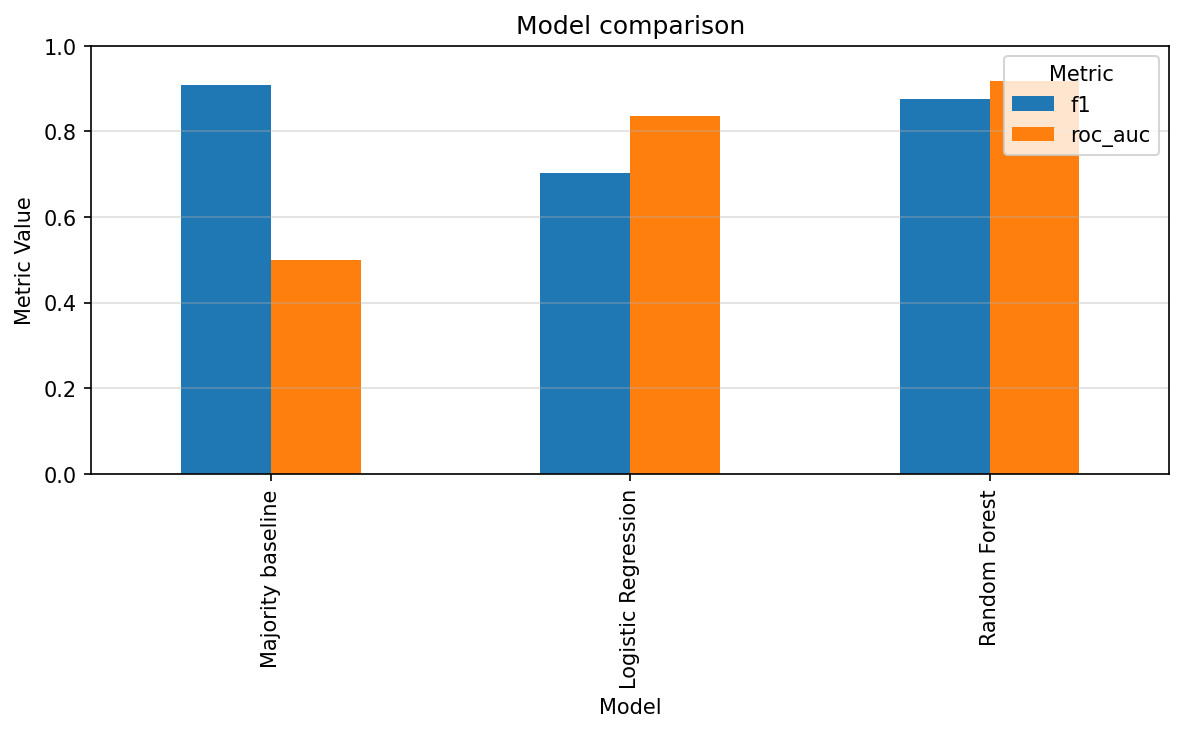

In [83]:
from src.modeling.evaluation import (
    save_model_comparison_plot,
    save_roc_curve,
    save_confusion_matrix_plot,
)

figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

comparison_plot_path = save_model_comparison_plot(
    test_comparison,
    output_path=figures_dir / "sprint2_prefix_model_comparison.png",
    metrics=["f1", "roc_auc"],
)

display(Image(comparison_plot_path))


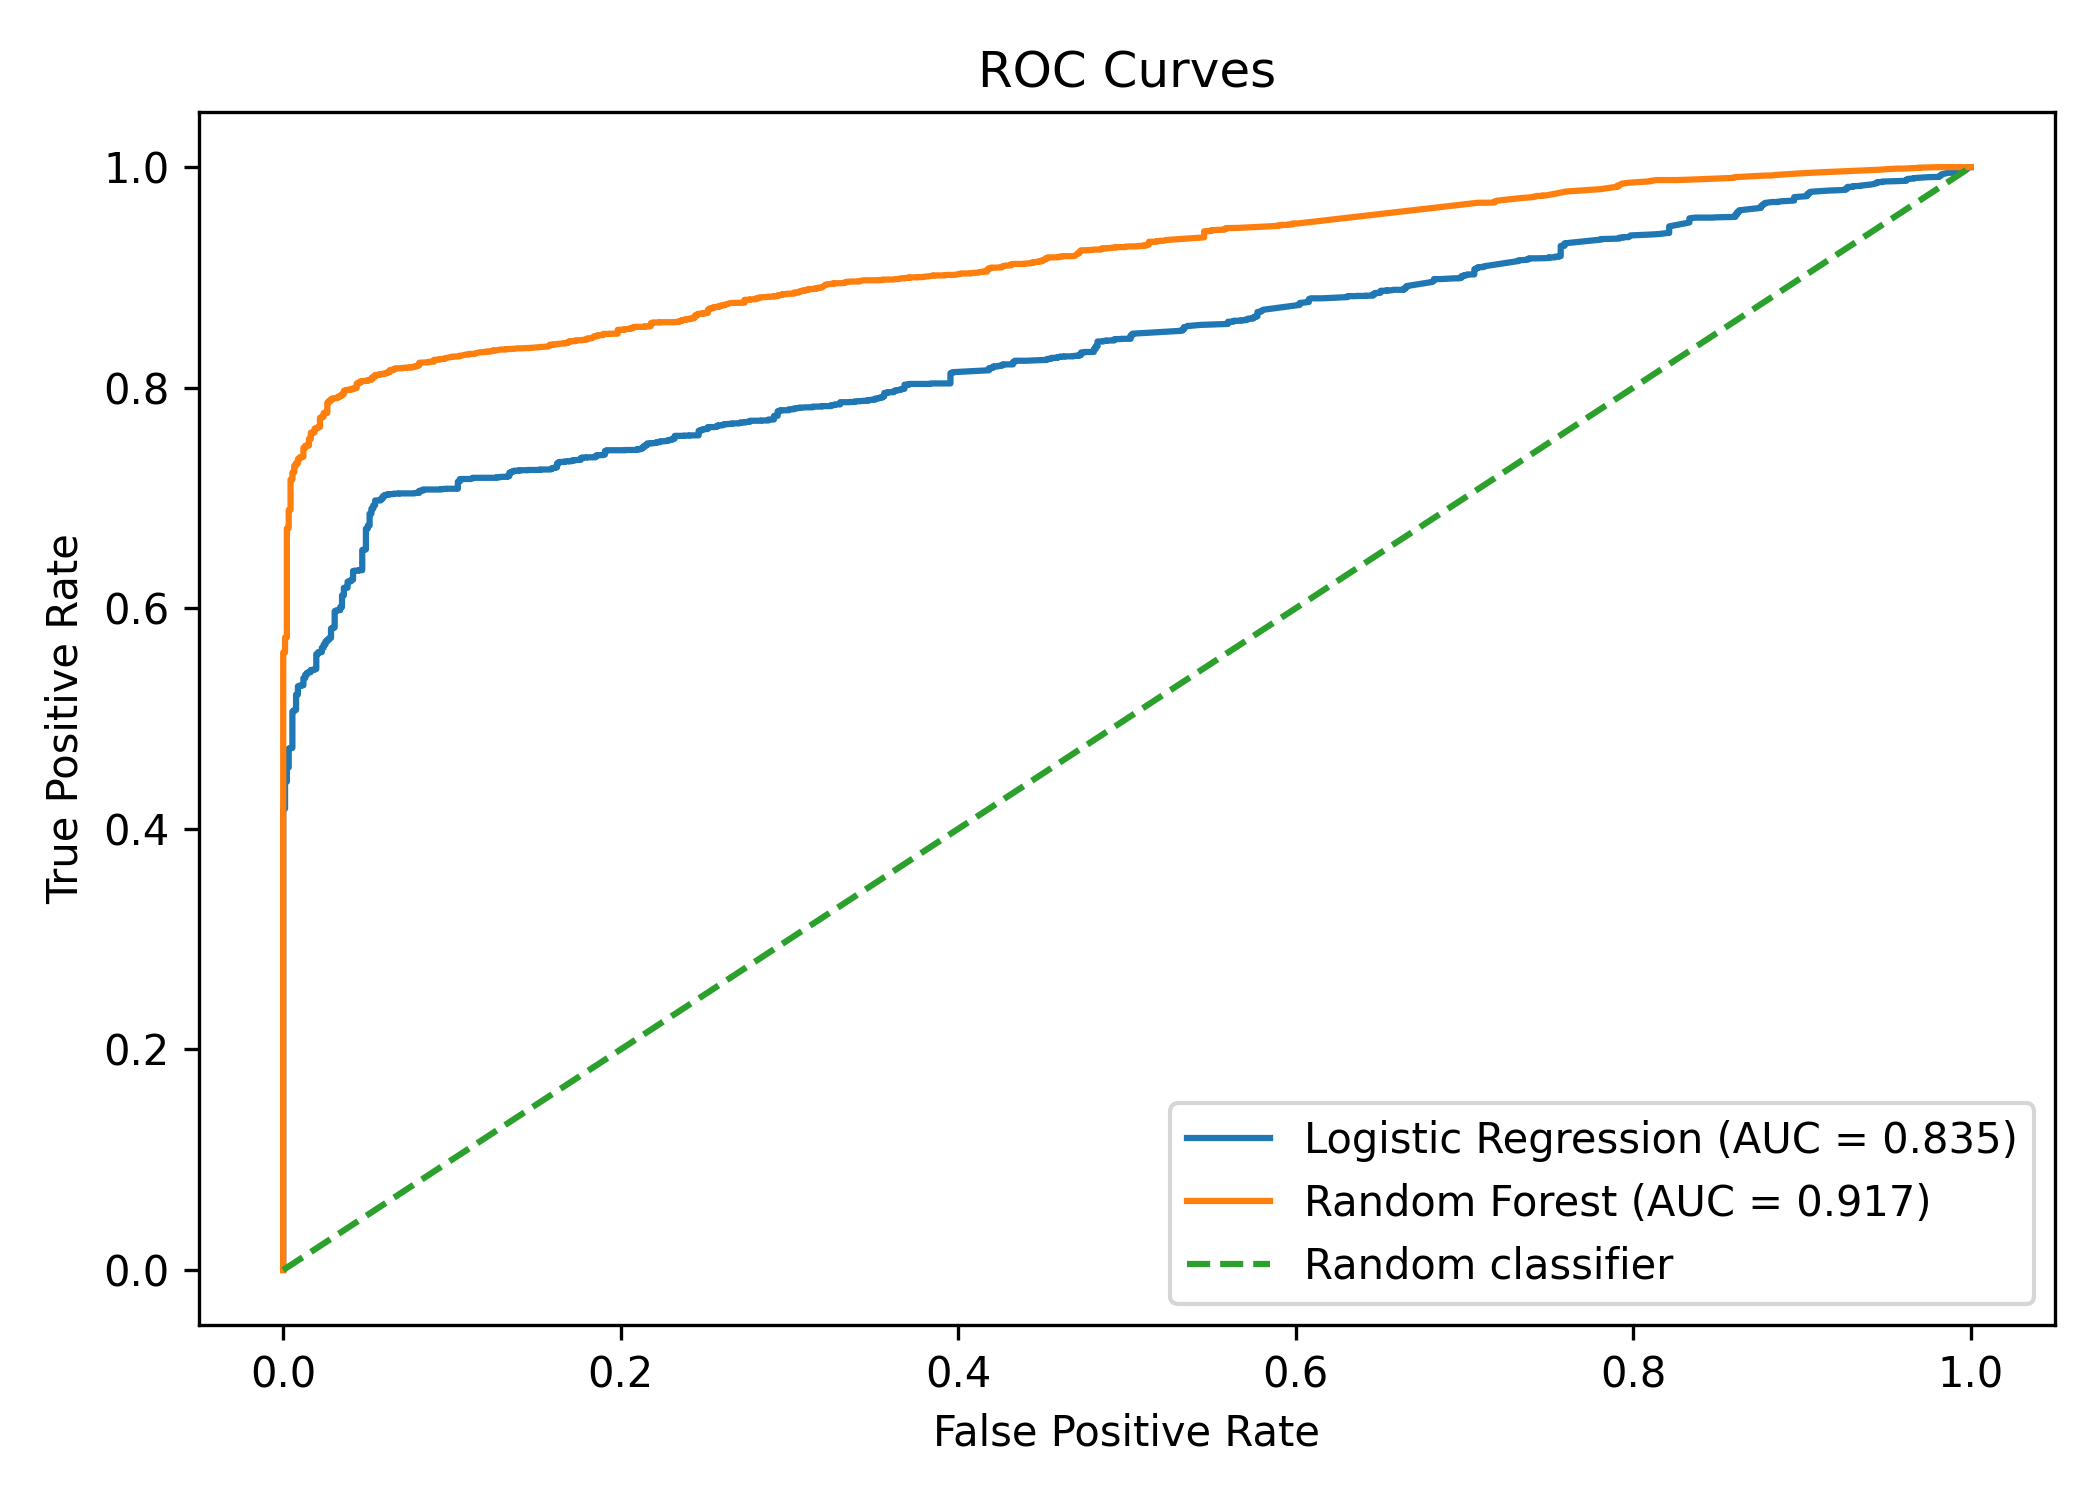

In [84]:
from src.modeling.evaluation import save_roc_curves

combined_roc_path = save_roc_curves(
    {
        "Logistic Regression": logreg.predict_proba(X_test)[:, 1],
        "Random Forest": best_rf.predict_proba(X_test)[:, 1],
    },
    y_test,
    figures_dir / "sprint2_prefix_combined_roc_curves.png",
)

display(Image(filename=combined_roc_path))

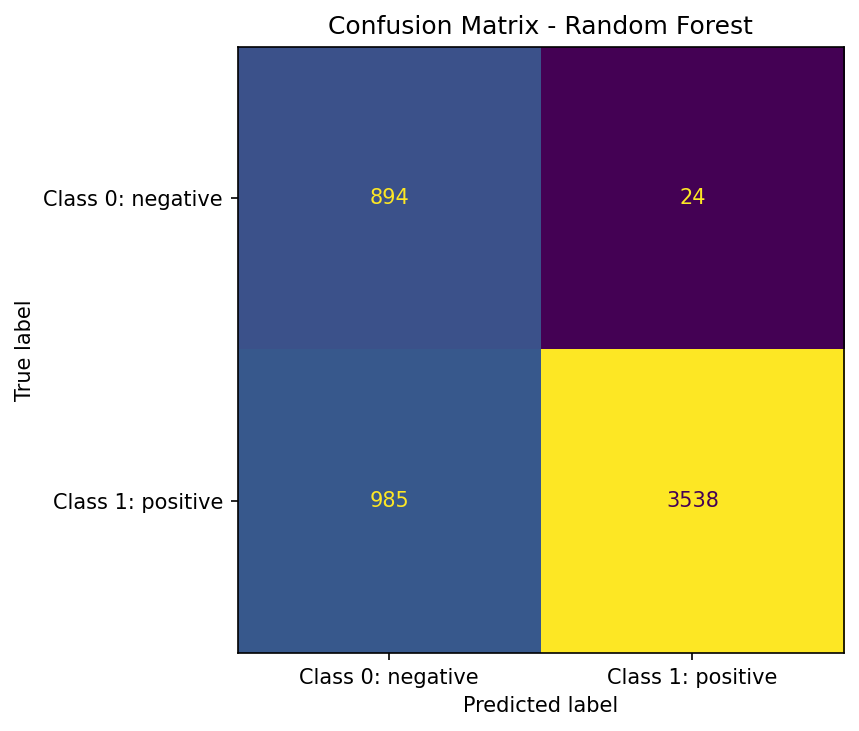

In [85]:
rf_test_pred = best_rf.predict(X_test)

rf_cm_path = save_confusion_matrix_plot(
    y_test,
    rf_test_pred,
    model_name="Random Forest",
    output_path=figures_dir / "sprint2_prefix_random_forest_confusion_matrix.png",
)

display(Image(rf_cm_path))

The plots give a more detailed view of the final test results. The comparison plot summarizes the main metrics, while the ROC curves show that the trained models provide more useful prediction scores than the majority baseline. The confusion matrix for the Random Forest shows how the selected black-box model behaves at the default decision threshold.

## 13. SHAP experiments

The selected Random Forest model is explained with SHAP on a sample of the test prefixes. The global explanation shows which features are most important overall, while the local explanations show why the model made specific predictions for selected cases.

In [86]:
from src.explainability.shap_explainer import (
    save_global_shap_importance_plot,
    save_global_shap_importance_table,
    save_selected_local_explanations,
)

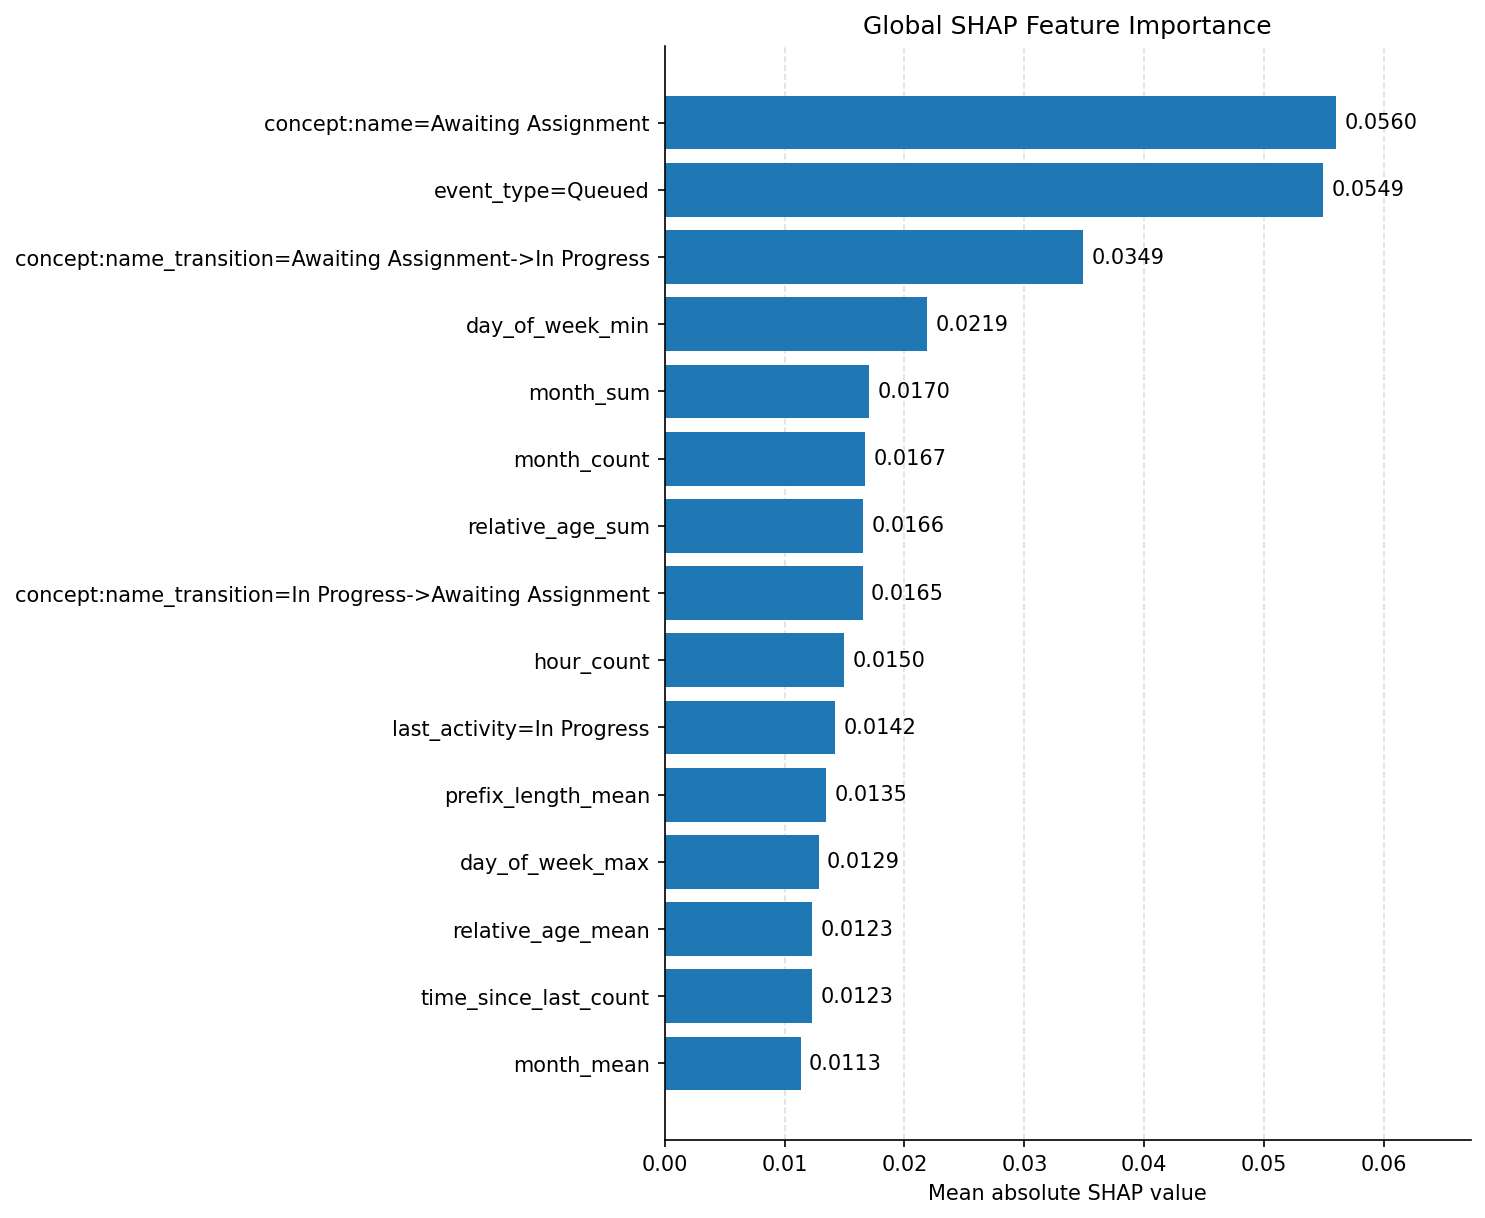

In [87]:
rf_test_pred = best_rf.predict(X_test)

shap_importance_plot_path = save_global_shap_importance_plot(
    model=best_rf,
    X=X_test,
    feature_columns=feature_columns,
    output_path=figures_dir / "sprint2_prefix_shap_importance.png",
    max_samples=500,
    top_n=15,
)

display(Image(shap_importance_plot_path))

The global SHAP importance plot shows that the Random Forest mainly relies on early process-state information, such as whether the prefix contains `Awaiting Assignment`, whether the original event type is `Queued`, and transitions from `Awaiting Assignment` to `In Progress`. Some temporal and prefix-progress features also appear among the important features. Since the final outcome is now based on the final process state rather than case duration, these time-related features are less directly leaking the target, but they should still be interpreted carefully.

In [88]:
shap_importance_table = save_global_shap_importance_table(
    model=best_rf,
    X=X_test,
    feature_columns=feature_columns,
    output_path=project_root / "reports" / "sprint2_prefix_shap_importance.csv",
    max_samples=500,
)

shap_importance_table.head(10)

,feature,mean_abs_shap
82,concept:name=Awaiting Assignment,0.056013
79,event_type=Queued,0.054908
99,concept:name_transition=Awaiting Assignment->I...,0.034904
195,day_of_week_min,0.021879
205,month_sum,0.017049
210,month_count,0.016706
211,relative_age_sum,0.016577
109,concept:name_transition=In Progress->Awaiting ...,0.016518
192,hour_count,0.014953
228,last_activity=In Progress,0.014197


The SHAP importance table confirms the same pattern as the plot. The strongest features are related to the current process state and prefix behavior, especially `Awaiting Assignment`, `Queued`, and transitions between `Awaiting Assignment` and `In Progress`. This suggests that the model mainly uses information about the early state of the incident process rather than only relying on generic metadata.

In [ ]:
local_shap_paths = save_selected_local_explanations(
    model=best_rf,
    X=X_test,
    feature_columns=feature_columns,
    y_true=y_test,
    y_pred=rf_test_pred,
    output_dir=figures_dir / "explanations",
)

from IPython.display import Markdown

for explanation_type, path in local_shap_paths.items():
    display(Markdown(f"### {explanation_type.replace('_', ' ').title()}"))
    display(Image(filename=str(path)))

The SHAP plots confirm that explanations can be generated for the selected Random Forest model and the final prefix-level feature representation. The importance table gives a compact overview of the globally most influential features, while the local plots show individual prediction explanations.

## Summary

This notebook shows the final Sprint 2 pipeline on prefix-level event log data. Since `lifecycle:transition` contains the more meaningful process states in this dataset, it is used as the activity column for feature encoding. The outcome is defined from the final process state of each case, where cases ending in `Closed` or `Resolved` are treated as positive outcomes.

The original cases are split into train, validation, and test sets before prefix generation. This prevents prefixes from the same case from appearing in different splits. After that, prefixes are generated separately for each split and encoded into aligned feature matrices using the training feature columns.

The notebook compares a majority baseline, Logistic Regression, and Random Forest. Random Forest configurations are selected on the validation set using F1 score, and the final models are evaluated on the test set. The baseline remains strong in accuracy and F1 because the prefix labels are imbalanced, but its ROC AUC is 0.5. The trained models, especially Random Forest, provide better ROC AUC and therefore better actual discrimination between positive and negative cases.

Finally, SHAP explanations are generated for the selected Random Forest model. The global explanations show that the model mainly relies on process-state and prefix-progress features, such as `Awaiting Assignment`, `Queued`, and transitions into `In Progress`. Local explanations are also generated for selected individual predictions.